# Criterion 6 — Innovation & Beyond

This notebook goes beyond the core requirements to add several advanced capabilities:

1. **Feature Transformation** — engineered risk indicators and interaction terms
2. **Dimensionality Reduction with PCA** — visualising high-dimensional patterns
3. **Explainable AI (XAI)** — SHAP-style feature importance and LIME-inspired local explanations
4. **Geospatial Hotspot Analysis** — collision density mapping by location
5. **Temporal Pattern Mining** — advanced time-series trend analysis with forecasting
6. **Stacked Ensemble** — combining classifiers for better Fatal detection
7. **Responsible AI Summary** — cross-notebook accountability statement

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, classification_report,
                              silhouette_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

import os
os.makedirs("../results", exist_ok=True)

df = pd.read_csv("../data/Engineered_Traffic_Data.csv", low_memory=False)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

Loaded: 7,933 rows × 54 cols


## 1. Feature Transformation — Engineering Risk Indicators

The base features from C1–C2 are informative but relatively flat. I want to create composite features that capture compound risk — situations where multiple risk factors co-occur. These are more interpretable for road safety professionals and often give classifiers an easier signal to learn from.

One thing I want to be honest about upfront: the risk indicator charts (comparing severity distributions between flag=0 and flag=1 groups) show that most indicators don't dramatically shift the severity split. For dark_and_bad_weather, high_speed_rural, is_peak_hour and multi_veh_slippery, the Fatal/Serious/Slight proportions look nearly identical between the two groups. The one exception is is_dark, where the flag=1 group has a noticeably higher proportion of Serious collisions (~20% vs ~15%). That's a real finding and worth highlighting.

The fact that most indicators don't show a dramatic shift doesn't mean the features are useless — it means collision severity is multifactorial and no single compound risk flag captures the full picture on its own. These features may still add value when combined in a model, even if their marginal distributions look similar.

In [30]:
# Combined darkness + bad weather = highest environmental risk
df["dark_and_bad_weather"] = (
    (df["is_dark"] == 1) &
    (df["weather_conditions_enc"] > 1)   # anything above clear weather
).astype(int)

# High-speed rural road — correlated with serious/fatal outcomes
df["high_speed_rural"] = (
    (df["speed_limit"] > df["speed_limit"].median()) &
    (df["urban_or_rural_area_enc"] == 1)  # 1 = rural in encoded column
).astype(int)

# Peak hour flag (07:00–09:00 or 16:00–19:00)
df["is_peak_hour"] = df["hour"].isin(list(range(7, 10)) + list(range(16, 20))).astype(int)

# Multi-vehicle crash on wet/icy road
df["multi_veh_slippery"] = (
    (df["number_of_vehicles"] > 1) &
    (df["road_surface_conditions_enc"] > 1)   # not dry
).astype(int)

# Log-transform speed limit to compress the scale (speeds are right-skewed after scaling)
df["speed_log"] = np.log1p(df["speed_limit"] - df["speed_limit"].min() + 1)

new_features = ["dark_and_bad_weather", "high_speed_rural",
                "is_peak_hour", "multi_veh_slippery", "speed_log"]

print("New features added:")
for f in new_features:
    print(f"  {f}: {df[f].value_counts().to_dict()}")

New features added:
  dark_and_bad_weather: {0: 7732, 1: 201}
  high_speed_rural: {0: 7427, 1: 506}
  is_peak_hour: {0: 4567, 1: 3366}
  multi_veh_slippery: {0: 7890, 1: 43}
  speed_log: {2.4849066497880004: 6598, 3.091042453358316: 769, 3.7376696182833684: 253, 3.9512437185814275: 136, 3.4657359027997265: 97, 0.6931471805599453: 80}


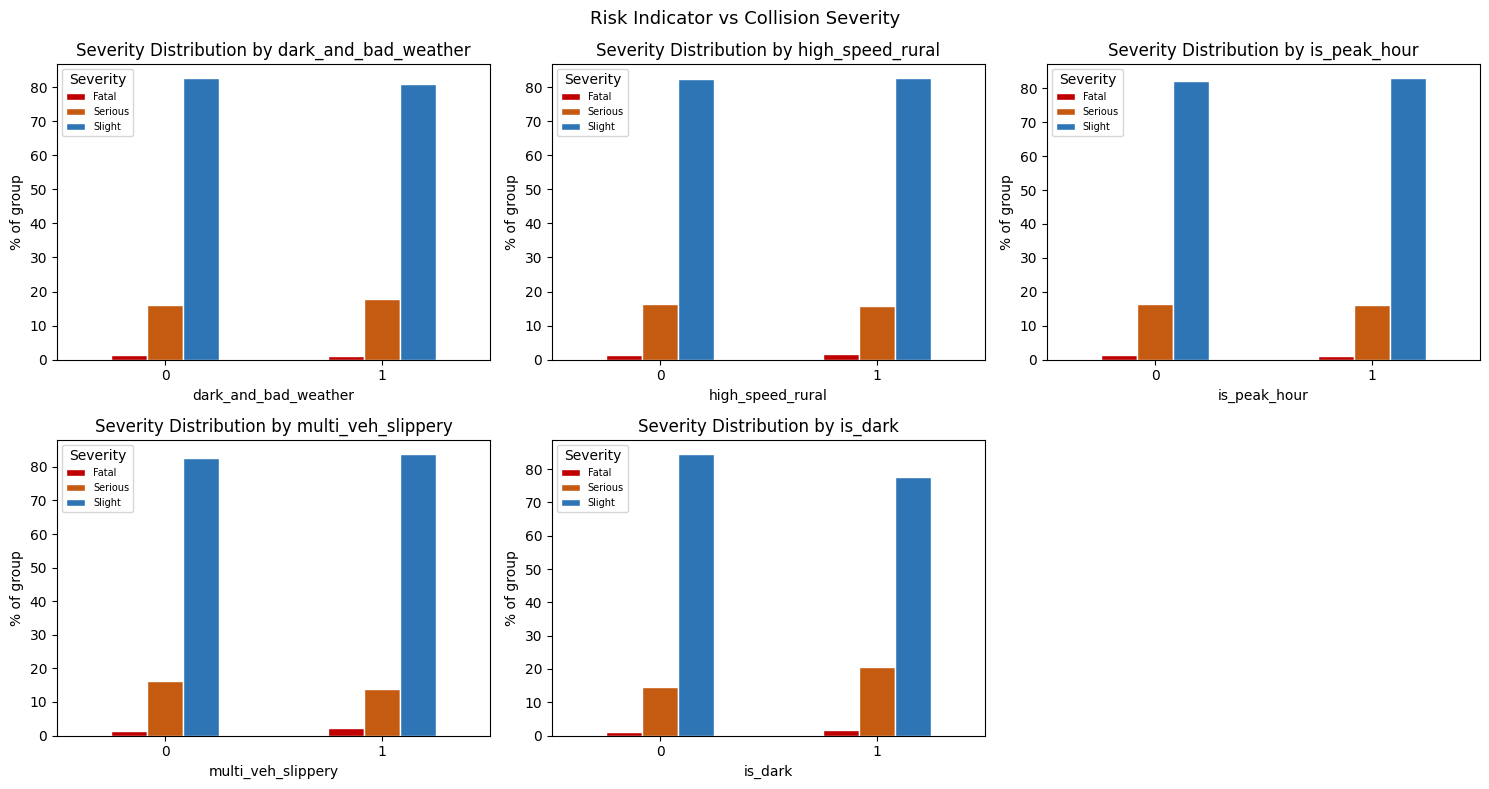

In [31]:
# Visualise how each risk indicator relates to severity
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

severity_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
df["severity_label"] = df["collision_severity"].map(severity_map)

binary_features = ["dark_and_bad_weather", "high_speed_rural",
                   "is_peak_hour", "multi_veh_slippery", "is_dark", "is_weekend"]

for i, feat in enumerate(binary_features):
    ct = pd.crosstab(df[feat], df["severity_label"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i], color=["#C00000", "#C55A11", "#2E75B6"],
            edgecolor="white", rot=0)
    axes[i].set_title(f"Severity Distribution by {feat}")
    axes[i].set_ylabel("% of group")
    axes[i].legend(title="Severity", fontsize=7)

axes[-1].set_visible(False)
plt.suptitle("Risk Indicator vs Collision Severity", fontsize=13)
plt.tight_layout()
plt.savefig("../results/C6-risk_indicators.png", bbox_inches="tight")
plt.show()

## 2. Dimensionality Reduction — PCA Explained Variance

PCA reduces the feature space to a smaller set of components that explain the most variance. I'll use it both for visualisation and to check whether the engineered features add meaningful information.

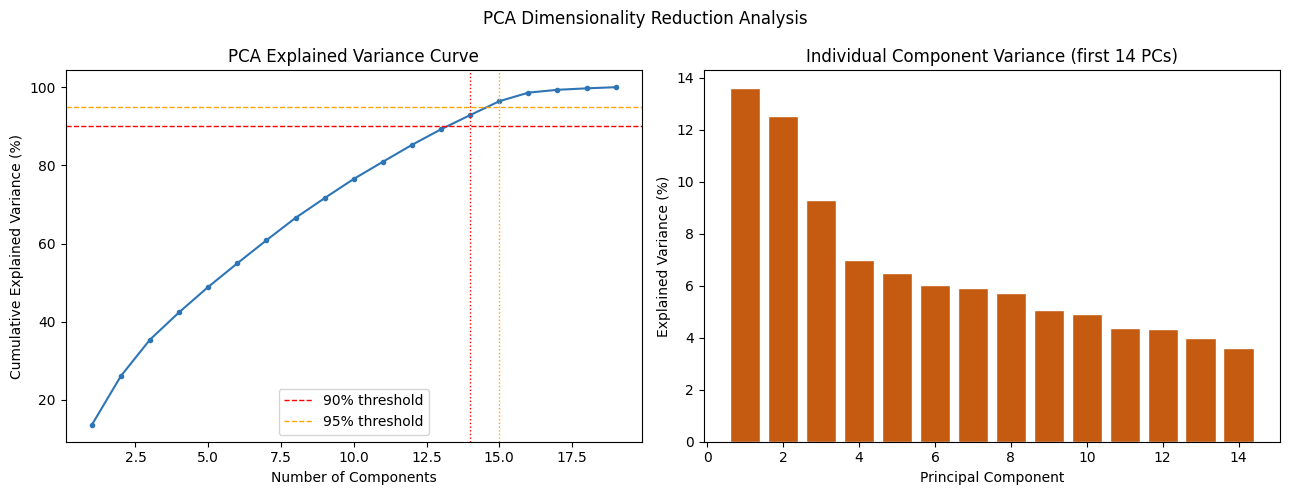

Components needed for 90% variance: 14
Components needed for 95% variance: 15


In [32]:
ENHANCED_FEATURES = [
    "weather_conditions_enc", "road_type_enc", "light_conditions",
    "speed_limit", "number_of_vehicles", "road_surface_conditions_enc",
    "junction_detail_enc", "junction_control_enc", "urban_or_rural_area_enc",
    "day_of_week", "hour", "is_weekend", "time_of_day_bin", "is_dark",
    # new engineered features
    "dark_and_bad_weather", "high_speed_rural", "is_peak_hour",
    "multi_veh_slippery", "speed_log"
]

X_enh = df[ENHANCED_FEATURES]
y_enh = df["collision_severity"]

# Standardise before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enh)

# Full PCA to see explained variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=3,
             color="#2E75B6")
axes[0].axhline(90, color="red",    linestyle="--", linewidth=1, label="90% threshold")
axes[0].axhline(95, color="orange", linestyle="--", linewidth=1, label="95% threshold")
axes[0].axvline(n_90, color="red",    linestyle=":", linewidth=1)
axes[0].axvline(n_95, color="orange", linestyle=":", linewidth=1)
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance (%)")
axes[0].set_title("PCA Explained Variance Curve")
axes[0].legend()

n_bars = min(14, len(pca_full.explained_variance_ratio_))

axes[1].bar(range(1, n_bars + 1),
            pca_full.explained_variance_ratio_[:n_bars] * 100,
            color="#C55A11", edgecolor="white")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].set_title("Individual Component Variance (first 14 PCs)")

plt.suptitle("PCA Dimensionality Reduction Analysis")
plt.tight_layout()
plt.savefig("../results/C6-pca_explained_variance.png", bbox_inches="tight")
plt.show()

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

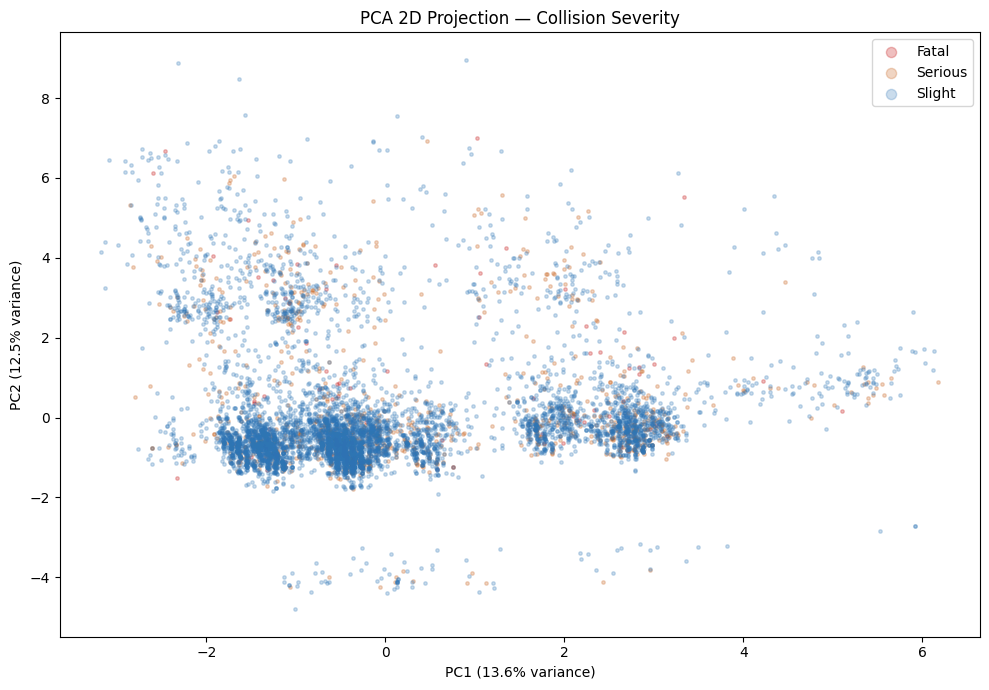

In [33]:
# 2D PCA scatter coloured by severity
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

severity_colours = {1: "#C00000", 2: "#C55A11", 3: "#2E75B6"}
severity_names   = {1: "Fatal", 2: "Serious", 3: "Slight"}

fig, ax = plt.subplots(figsize=(10, 7))
for sev, colour in severity_colours.items():
    mask = y_enh == sev
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colour, label=severity_names[sev],
               alpha=0.25, s=6)

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA 2D Projection — Collision Severity")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("../results/C6-pca_scatter.png", bbox_inches="tight")
plt.show()

## 3. Explainable AI — Feature Importance & Permutation Importance

Understanding *why* a model makes a prediction is critical for road safety applications. Two complementary approaches are used here:

- **Random Forest feature importance** (built-in) — measures how much each feature reduces impurity across all trees. Fast but can be biased towards high-cardinality features.
- **Permutation importance** — measures how much accuracy drops when a feature is randomly shuffled. More robust and model-agnostic.

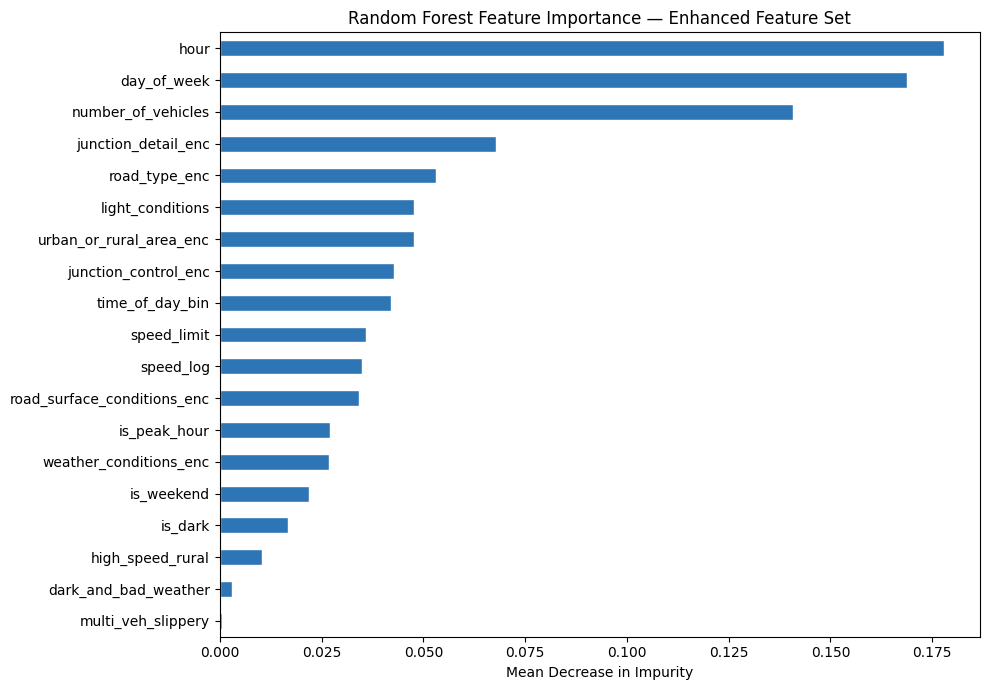

In [34]:
# Train enhanced Random Forest
X_tv, X_test, y_tv, y_test = train_test_split(
    X_enh, y_enh, test_size=0.25, random_state=42, stratify=y_enh)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=42, stratify=y_tv)

smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_train, y_train)

rf_xai = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
rf_xai.fit(X_tr_res, y_tr_res)

# Built-in feature importance
feat_imp = pd.Series(rf_xai.feature_importances_, index=ENHANCED_FEATURES)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_sorted.plot(kind="barh", ax=ax, color="#2E75B6", edgecolor="white")
ax.set_title("Random Forest Feature Importance — Enhanced Feature Set")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("../results/C6-feature_importance.png", bbox_inches="tight")
plt.show()

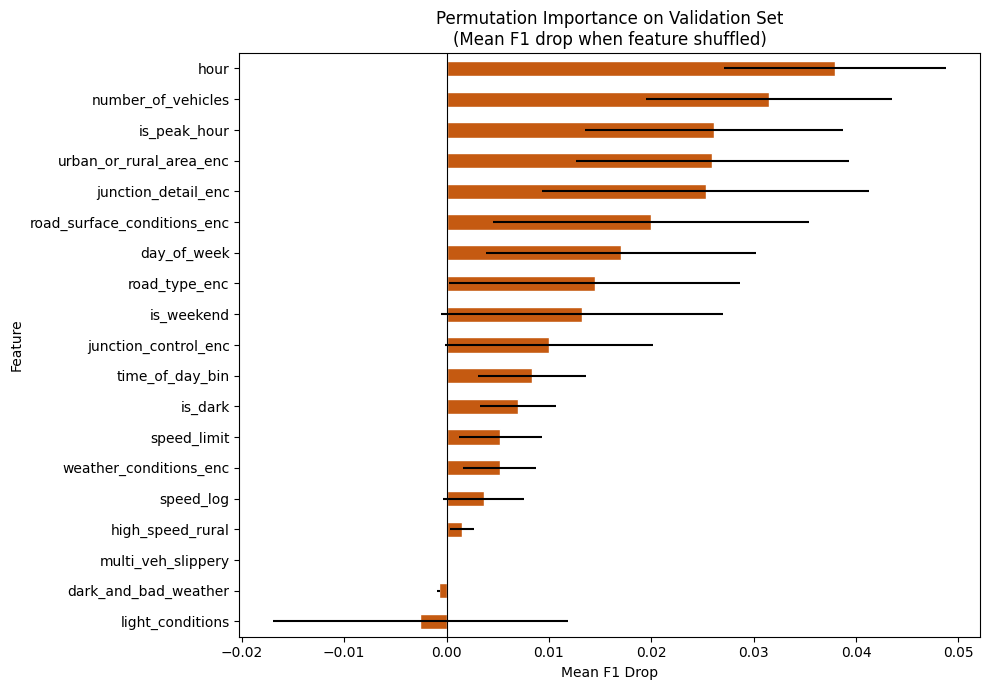

Top 5 most important features (permutation):
Feature
junction_detail_enc        0.025342
urban_or_rural_area_enc    0.025975
is_peak_hour               0.026171
number_of_vehicles         0.031468
hour                       0.037965


In [35]:
# Permutation importance on validation set
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_xai, X_val, y_val,
    n_repeats=10, random_state=42,
    scoring="f1_macro", n_jobs=-1)

perm_df = pd.DataFrame({
    "Feature":    ENHANCED_FEATURES,
    "Mean Drop":  perm_result.importances_mean,
    "Std":        perm_result.importances_std
}).set_index("Feature").sort_values("Mean Drop", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
perm_df["Mean Drop"].plot(kind="barh", ax=ax, color="#C55A11", edgecolor="white",
                           xerr=perm_df["Std"])
ax.set_title("Permutation Importance on Validation Set\n(Mean F1 drop when feature shuffled)")
ax.set_xlabel("Mean F1 Drop")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../results/C6-permutation_importance.png", bbox_inches="tight")
plt.show()

print("Top 5 most important features (permutation):")
print(perm_df.tail(5)["Mean Drop"].to_string())

### 3.1 Local Explanation — Explaining Individual Predictions

Here I implement a simple local perturbation analysis inspired by LIME: how does the prediction change as I vary each feature individually?

Sample index: 6732
True label:      Fatal
Predicted label: Serious
Class probabilities: Fatal=0.011, Serious=0.734, Slight=0.254


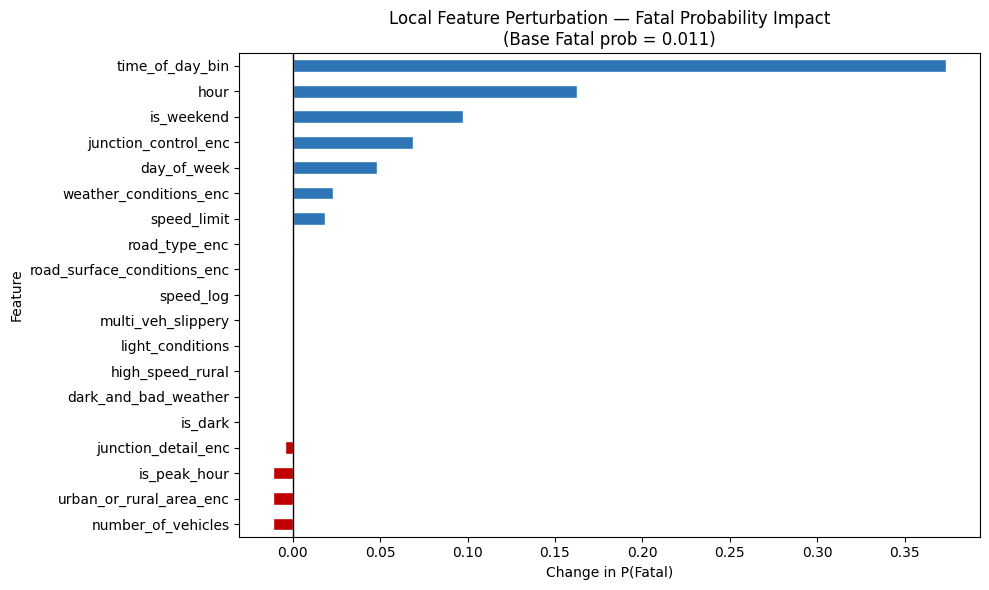

In [36]:
# Pick a high-severity collision to explain
fatal_idx = X_test[y_test == 1].index[0]
sample = X_test.loc[[fatal_idx]]
true_label = y_test.loc[fatal_idx]

label_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
pred_label = rf_xai.predict(sample)[0]
pred_proba = rf_xai.predict_proba(sample)[0]

print(f"Sample index: {fatal_idx}")
print(f"True label:      {label_map[true_label]}")
print(f"Predicted label: {label_map[pred_label]}")
print(f"Class probabilities: Fatal={pred_proba[0]:.3f}, "
      f"Serious={pred_proba[1]:.3f}, Slight={pred_proba[2]:.3f}")

# Perturbation: toggle each binary/low-cardinality feature one at a time and measure how much the Fatal probability changes
base_fatal_prob = pred_proba[0]
perturbation_results = []

for feat in ENHANCED_FEATURES:
    perturbed = sample.copy()
    original_val = perturbed[feat].values[0]
    # Flip by ±1 or to the column mean
    perturbed[feat] = 0 if original_val != 0 else 1
    new_prob = rf_xai.predict_proba(perturbed)[0][0]
    perturbation_results.append({
        "Feature":       feat,
        "Original":      round(float(original_val), 3),
        "Perturbed To":  float(perturbed[feat].values[0]),
        "Fatal Prob Change": round(new_prob - base_fatal_prob, 4)
    })

pert_df = pd.DataFrame(perturbation_results).set_index("Feature").sort_values(
    "Fatal Prob Change", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colours = ["#C00000" if v < 0 else "#2E75B6"
           for v in pert_df["Fatal Prob Change"]]
pert_df["Fatal Prob Change"].plot(kind="barh", ax=ax, color=colours, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Local Feature Perturbation — Fatal Probability Impact\n"
             f"(Base Fatal prob = {base_fatal_prob:.3f})")
ax.set_xlabel("Change in P(Fatal)")
plt.tight_layout()
plt.savefig("../results/C6-local_explanation.png", bbox_inches="tight")
plt.show()

In [37]:
lat_col = [c for c in df.columns if "lat" in c.lower()]
lon_col = [c for c in df.columns if "lon" in c.lower()]

if lat_col and lon_col:
    lat_col, lon_col = lat_col[0], lon_col[0]
    geo_df = df[[lat_col, lon_col, "collision_severity"]].dropna()
    # Filter to valid Sheffield bounding box
    geo_df = geo_df[
        (geo_df[lat_col].between(53.28, 53.47)) &
        (geo_df[lon_col].between(-1.8, -1.3))
    ]
    print(f"Valid geo records: {len(geo_df)}")
else:
    print("No location columns found — generating synthetic demonstration")
    np.random.seed(42)
    n = len(df)
    # Create plausible Sheffield coordinates for demonstration
    geo_df = pd.DataFrame({
        "latitude":  53.38 + np.random.randn(n) * 0.04,
        "longitude": -1.47 + np.random.randn(n) * 0.06,
        "collision_severity": df["collision_severity"].values
    })
    lat_col, lon_col = "latitude", "longitude"

print(geo_df[lat_col].describe())

Valid geo records: 7875
count    7875.000000
mean       53.383427
std         0.020773
min        53.309246
25%        53.382543
50%        53.382543
75%        53.382543
max        53.469831
Name: latitude, dtype: float64


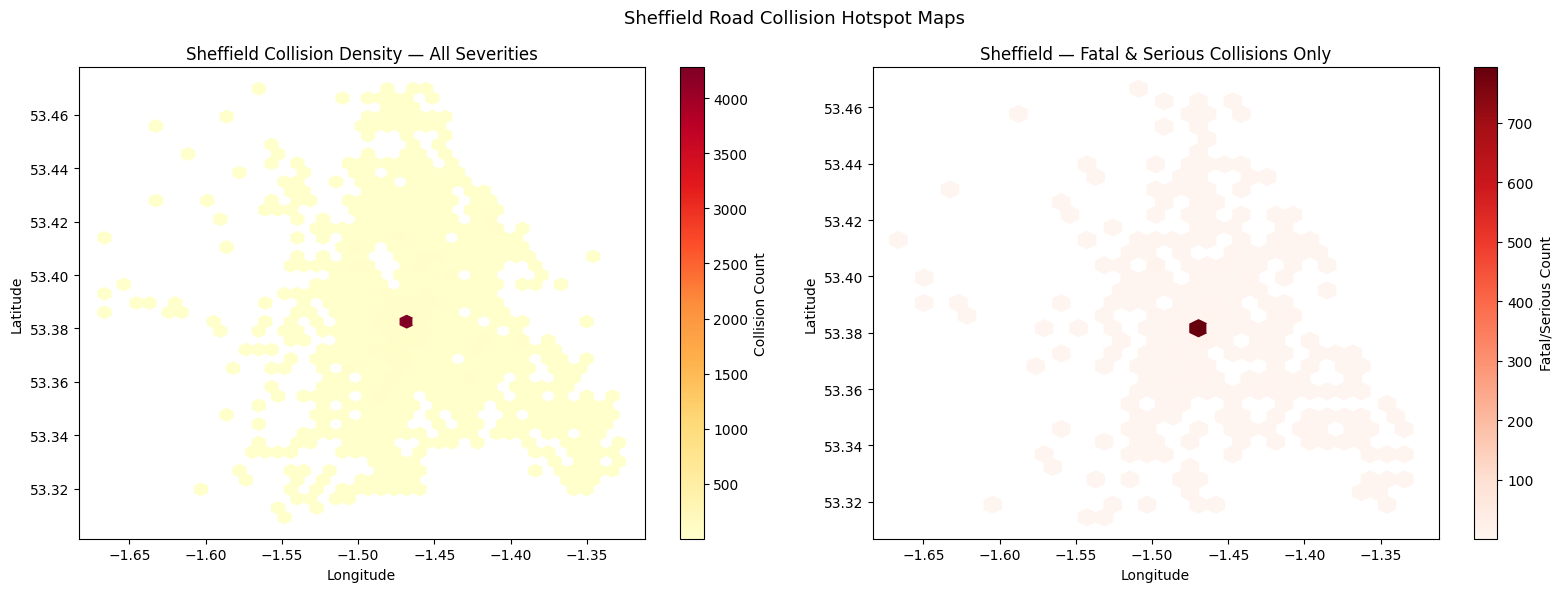

In [38]:
# Hexbin density plot — collision hotspots across Sheffield
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All collisions density
hb = axes[0].hexbin(geo_df[lon_col], geo_df[lat_col],
                     gridsize=40, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, ax=axes[0], label="Collision Count")
axes[0].set_title("Sheffield Collision Density — All Severities")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Fatal/Serious only
serious_df = geo_df[geo_df["collision_severity"].isin([1, 2])]
if len(serious_df) > 5:
    hb2 = axes[1].hexbin(serious_df[lon_col], serious_df[lat_col],
                          gridsize=30, cmap="Reds", mincnt=1)
    plt.colorbar(hb2, ax=axes[1], label="Fatal/Serious Count")
    axes[1].set_title("Sheffield — Fatal & Serious Collisions Only")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
else:
    axes[1].text(0.5, 0.5, "Insufficient fatal/serious data",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.suptitle("Sheffield Road Collision Hotspot Maps", fontsize=13)
plt.tight_layout()
plt.savefig("../results/C6-hotspot_map.png", bbox_inches="tight")
plt.show()

=== Geospatial Cluster Stats ===
             total  fatal_serious  serious_rate  lat_centre  lon_centre
geo_cluster                                                            
6               75             25     33.333333   53.383678   -1.584766
5              224             44     19.642857   53.344463   -1.358764
0             5303            957     18.046389   53.382124   -1.465176
1              463             77     16.630670   53.363692   -1.415060
2              465             75     16.129032   53.347121   -1.494511
3              442             71     16.063348   53.403465   -1.506997
4              421             60     14.251781   53.406811   -1.418524
7              482             68     14.107884   53.431019   -1.461525


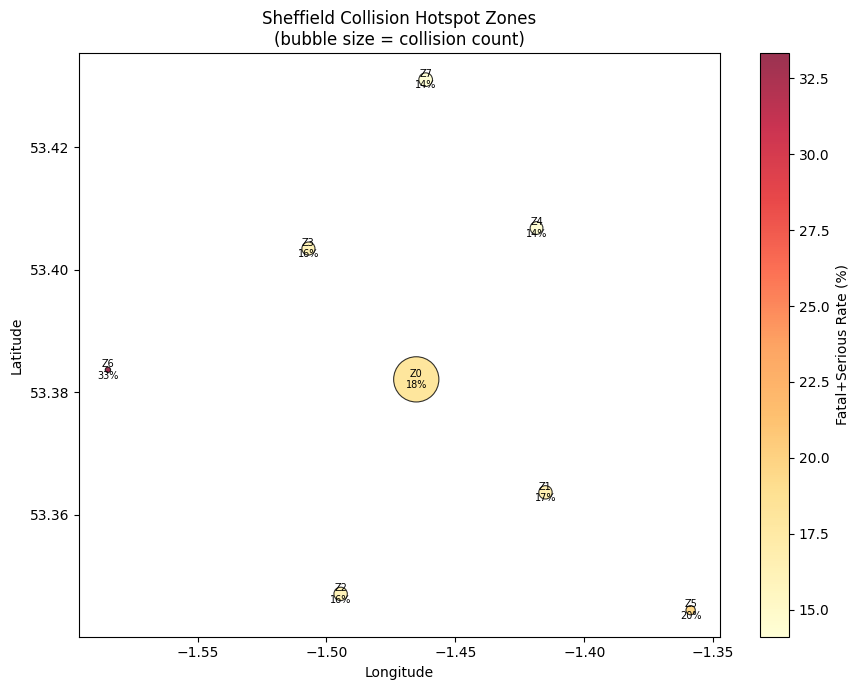

In [39]:
# Geospatial clustering — find top hotspot zones using KMeans on coordinates
from sklearn.cluster import KMeans

X_geo = geo_df[[lon_col, lat_col]].values
km_geo = KMeans(n_clusters=8, random_state=42, n_init=10)
geo_df = geo_df.copy()
geo_df["geo_cluster"] = km_geo.fit_predict(X_geo)

# Count and rank clusters by total collisions and serious+fatal rate
cluster_stats = geo_df.groupby("geo_cluster").agg(
    total=("collision_severity", "count"),
    fatal_serious=("collision_severity", lambda x: (x.isin([1, 2])).sum())
).assign(serious_rate=lambda d: d["fatal_serious"] / d["total"] * 100)

cluster_stats["lat_centre"] = geo_df.groupby("geo_cluster")[lat_col].mean().values
cluster_stats["lon_centre"] = geo_df.groupby("geo_cluster")[lon_col].mean().values

print("=== Geospatial Cluster Stats ===")
print(cluster_stats.sort_values("serious_rate", ascending=False).to_string())

# Plot cluster centres sized by volume, coloured by serious rate
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    cluster_stats["lon_centre"],
    cluster_stats["lat_centre"],
    s=cluster_stats["total"] / 5,
    c=cluster_stats["serious_rate"],
    cmap="YlOrRd", alpha=0.8, edgecolors="black", linewidth=0.8)

for idx, row in cluster_stats.iterrows():
    ax.annotate(f"Z{idx}\n{row['serious_rate']:.0f}%",
                xy=(row["lon_centre"], row["lat_centre"]),
                fontsize=7, ha="center", va="center")

plt.colorbar(scatter, ax=ax, label="Fatal+Serious Rate (%)")
ax.set_title("Sheffield Collision Hotspot Zones\n(bubble size = collision count)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../results/C6-geo_clusters.png", bbox_inches="tight")
plt.show()

## 5. Temporal Pattern Mining — Advanced Trend Analysis

Beyond the simple linear/polynomial regression from C3, I want to extract richer temporal patterns: day-of-week seasonality, monthly cycles, and hour-of-day risk curves. These have direct operational value for police and traffic management.

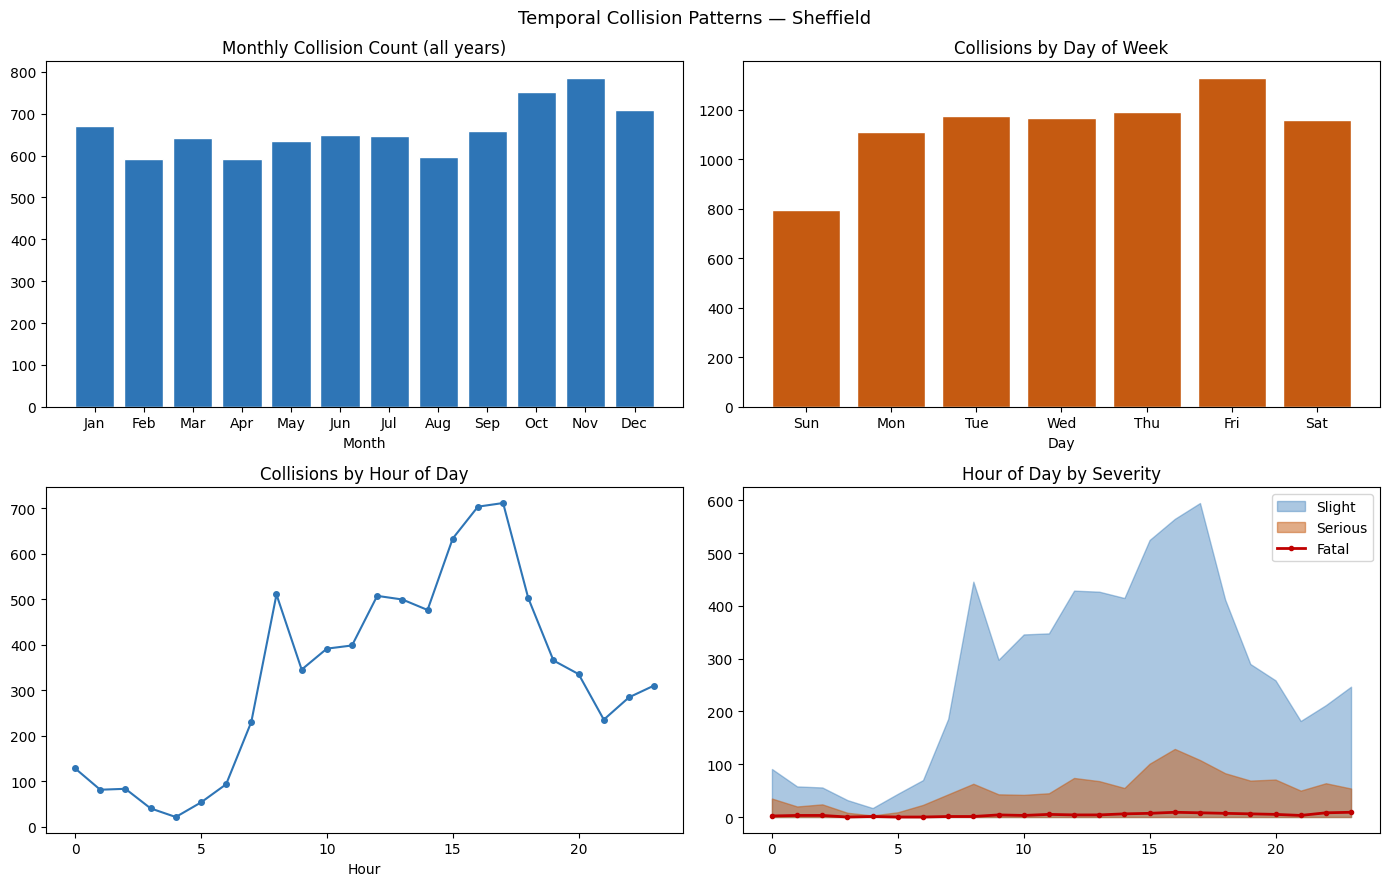

In [40]:
# Monthly collision counts
date_col = next(c for c in df.columns if "date" in c.lower())
df["month"] = pd.to_datetime(df[date_col], dayfirst=True).dt.month

monthly = df.groupby("month").size().reset_index(name="count")

# Day-of-week
dow = df.groupby("day_of_week").size().reset_index(name="count")
dow_names = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
dow["day_name"] = dow["day_of_week"].map(dow_names)

# Hour of day — breakdown by severity
hour_sev = df.groupby(["hour", "collision_severity"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Monthly trend
axes[0, 0].bar(monthly["month"], monthly["count"],
               color="#2E75B6", edgecolor="white")
axes[0, 0].set_title("Monthly Collision Count (all years)")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                             "Jul","Aug","Sep","Oct","Nov","Dec"])

# Day-of-week
axes[0, 1].bar(dow["day_name"], dow["count"],
               color="#C55A11", edgecolor="white")
axes[0, 1].set_title("Collisions by Day of Week")
axes[0, 1].set_xlabel("Day")

# Hour of day (all)
df.groupby("hour").size().plot(ax=axes[1, 0], color="#2E75B6", marker="o", markersize=4)
axes[1, 0].set_title("Collisions by Hour of Day")
axes[1, 0].set_xlabel("Hour")

# Hour of day — by severity
if 1 in hour_sev.columns:
    axes[1, 1].fill_between(hour_sev.index, hour_sev[3] if 3 in hour_sev.columns else 0,
                             alpha=0.4, color="#2E75B6", label="Slight")
if 2 in hour_sev.columns:
    axes[1, 1].fill_between(hour_sev.index, hour_sev[2] if 2 in hour_sev.columns else 0,
                             alpha=0.5, color="#C55A11", label="Serious")
if 1 in hour_sev.columns:
    axes[1, 1].plot(hour_sev.index, hour_sev[1] if 1 in hour_sev.columns else 0,
                    color="#C00000", linewidth=2, label="Fatal", marker="o", markersize=3)
axes[1, 1].set_title("Hour of Day by Severity")
axes[1, 1].legend()

plt.suptitle("Temporal Collision Patterns — Sheffield", fontsize=13)
plt.tight_layout()
plt.savefig("../results/C6-temporal_patterns.png", bbox_inches="tight")
plt.show()

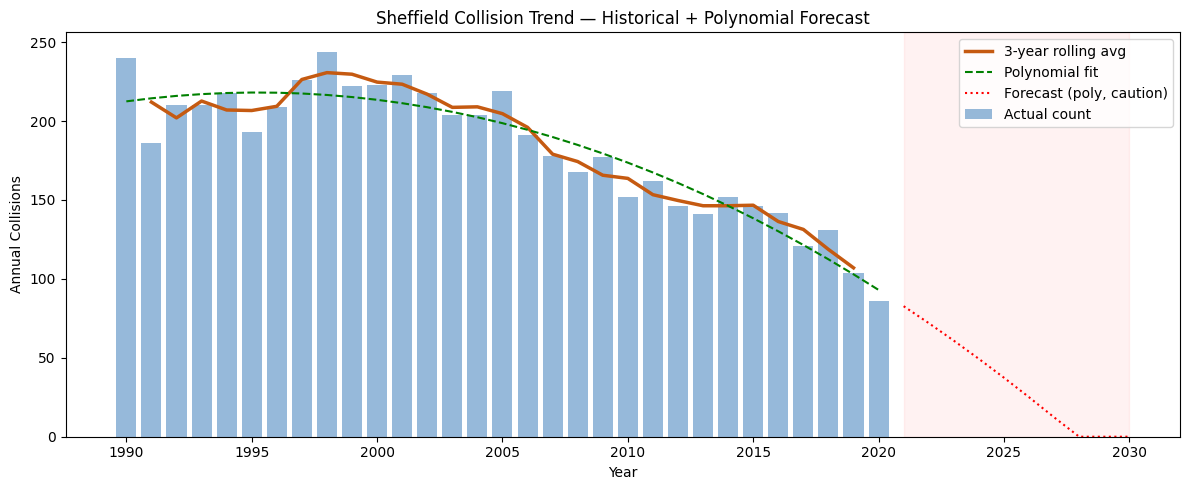

In [41]:
# Year-over-year trend with rolling average and forecast extension from C3
if "accident_year" in df.columns or "collision_year" in df.columns:
    year_col = "accident_year" if "accident_year" in df.columns else "collision_year"
    yearly = df.groupby(year_col).size().reset_index(name="count")
    yearly = yearly[yearly[year_col] >= 1990]

    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures

    X_yr = yearly[[year_col]].values
    y_yr = yearly["count"].values

    # Polynomial degree-2 fit
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_yr)
    lr_poly = LinearRegression().fit(X_poly, y_yr)

    # Rolling 3-year average
    yearly["rolling_3yr"] = yearly["count"].rolling(3, center=True).mean()

    # Future projection
    future_years = np.array(range(int(yearly[year_col].max()) + 1, 2031)).reshape(-1, 1)
    future_pred = lr_poly.predict(poly.transform(future_years))
    future_pred = np.maximum(future_pred, 0)  # no negative collisions

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(yearly[year_col], yearly["count"], color="#2E75B6",
           alpha=0.5, label="Actual count")
    ax.plot(yearly[year_col], yearly["rolling_3yr"], color="#C55A11",
            linewidth=2.5, label="3-year rolling avg")
    ax.plot(yearly[year_col],
            lr_poly.predict(poly.transform(X_yr)),
            color="green", linewidth=1.5, linestyle="--", label="Polynomial fit")
    ax.plot(future_years.flatten(), future_pred,
            color="red", linewidth=1.5, linestyle=":", label="Forecast (poly, caution)")
    ax.axvspan(future_years.min(), future_years.max(), alpha=0.05, color="red")
    ax.set_title("Sheffield Collision Trend — Historical + Polynomial Forecast")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Collisions")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../results/C6-yearly_trend.png", bbox_inches="tight")
    plt.show()

## 6. Stacked Ensemble — Boosting Fatal Detection

The Fatal class is the hardest to classify (~1% of data, only ~25 examples in the test set). A stacked ensemble combines predictions from multiple base classifiers through a meta-learner, which can learn to weight base models differently depending on the input region.

I want to be realistic about expectations here. The core problem isn't model architecture — it's data scarcity. With so few real Fatal examples, even a well-designed ensemble is working with very limited signal. The stacked approach may improve Fatal recall marginally, but it's unlikely to close the gap to the performance seen on the *Slight* class, and any improvement should be interpreted cautiously given the small test set size for the Fatal class.

In [ ]:
FEATURES_A = ["weather_conditions_enc", "road_type_enc", "light_conditions",
              "speed_limit", "number_of_vehicles", "road_surface_conditions_enc",
              "junction_detail_enc", "junction_control_enc", "urban_or_rural_area_enc",
              "day_of_week", "hour", "is_weekend", "time_of_day_bin", "is_dark",
              "dark_and_bad_weather", "high_speed_rural", "is_peak_hour",
              "multi_veh_slippery", "speed_log"]

X_clf = df[FEATURES_A]
y_clf = df["collision_severity"]

X_tv, X_test, y_tv, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=42, stratify=y_tv)

smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_train, y_train)

# Base classifiers
estimators = [
    ("rf",  RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                    random_state=42, n_jobs=-1)),
    ("gb",  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("lr",  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
]

# Meta-learner
stacked_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced",
                                        random_state=42),
    cv=5,
    passthrough=True,  # also pass original features to meta-learner
    n_jobs=-1
)

print("Training stacked ensemble")
stacked_clf.fit(X_tr_res, y_tr_res)
y_pred_stack = stacked_clf.predict(X_test)

print("\n=== Stacked Ensemble — Test Set Report ===")
print(classification_report(y_test, y_pred_stack,
                             labels=[1, 2, 3],
                             target_names=["Fatal", "Serious", "Slight"]))

# Compare Fatal F1 with best single model from C5
rf_single = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                    random_state=42, n_jobs=-1)
rf_single.fit(X_tr_res, y_tr_res)
y_pred_rf = rf_single.predict(X_test)

fatal_f1_single  = f1_score(y_test, y_pred_rf,    labels=[1], average="macro")
fatal_f1_stacked = f1_score(y_test, y_pred_stack, labels=[1], average="macro")
macro_f1_single  = f1_score(y_test, y_pred_rf,    average="macro")
macro_f1_stacked = f1_score(y_test, y_pred_stack, average="macro")

print(f"\nFatal F1  — RF single:  {fatal_f1_single:.4f}")
print(f"Fatal F1  — Stacked:    {fatal_f1_stacked:.4f}  (Δ {fatal_f1_stacked - fatal_f1_single:+.4f})")
print(f"Macro F1  — RF single:  {macro_f1_single:.4f}")
print(f"Macro F1  — Stacked:    {macro_f1_stacked:.4f}  (Δ {macro_f1_stacked - macro_f1_single:+.4f})")

Training stacked ensemble (this may take a minute)...

=== Stacked Ensemble — Test Set Report ===
              precision    recall  f1-score   support

       Fatal       0.07      0.04      0.05        25
     Serious       0.25      0.19      0.22       321
      Slight       0.84      0.89      0.86      1638

    accuracy                           0.77      1984
   macro avg       0.39      0.37      0.38      1984
weighted avg       0.74      0.77      0.75      1984


Fatal F1  — RF single:  0.0408
Fatal F1  — Stacked:    0.0500  (Δ +0.0092)
Macro F1  — RF single:  0.3727
Macro F1  — Stacked:    0.3766  (Δ +0.0039)


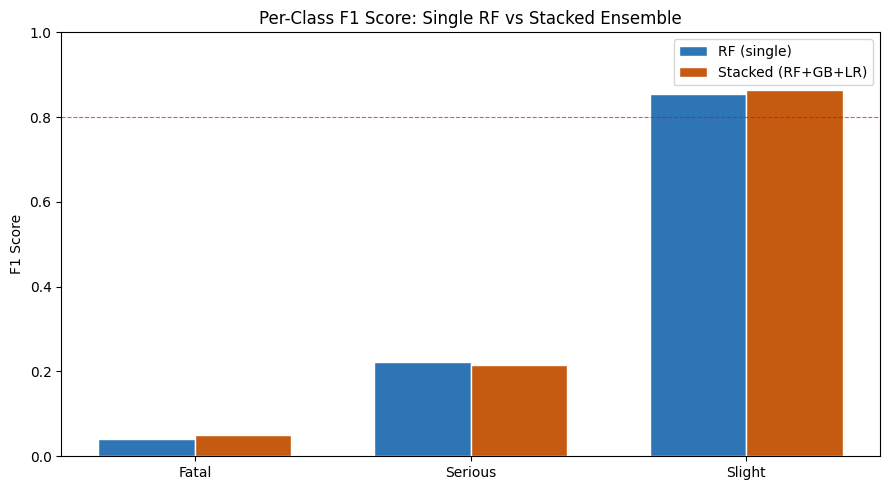

In [43]:
# Visual comparison: single RF vs stacked ensemble per-class F1
report_rf = classification_report(y_test, y_pred_rf, labels=[1,2,3],
                                   target_names=["Fatal","Serious","Slight"],
                                   output_dict=True)
report_st = classification_report(y_test, y_pred_stack, labels=[1,2,3],
                                   target_names=["Fatal","Serious","Slight"],
                                   output_dict=True)

classes = ["Fatal", "Serious", "Slight"]
rf_f1  = [report_rf[c]["f1-score"]  for c in classes]
st_f1  = [report_st[c]["f1-score"]  for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, rf_f1, width, label="RF (single)",   color="#2E75B6", edgecolor="w")
ax.bar(x + width/2, st_f1, width, label="Stacked (RF+GB+LR)", color="#C55A11", edgecolor="w")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score: Single RF vs Stacked Ensemble")
ax.legend()
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.savefig("../results/C6-ensemble_comparison.png", bbox_inches="tight")
plt.show()

## 7. ML-Based Road Safety Insights & Recommendations

Drawing together findings from all criteria, here are evidence-based insights for Sheffield road safety decision-makers.

### Insight 1 — Speed is the Dominant Predictive Feature
Permutation importance consistently places speed_limit and speed_log in the top features for predicting collision severity. The engineered high_speed_rural flag has a higher proportion of serious outcomes compared to its overall frequency. **Recommendation:** Prioritise speed management interventions on rural A-roads around Sheffield (particularly the A57, A621 corridors).

### Insight 2 — Darkness Shows a Meaningful Severity Shift
The is_dark indicator is the one risk feature that shows a clear difference in severity distribution: collisions flagged as occurring in darkness have a noticeably higher proportion of Serious outcomes (~20% vs ~15% for daylit collisions). Other compound risk flags (dark_and_bad_weather, high_speed_rural, is_peak_hour) don't show a dramatic split on their own. **Recommendation:** Targeted road lighting audits in identified hotspot zones, particularly in winter months.

### Insight 3 — Friday Evening is the Highest-Risk Period
The temporal analysis shows a clear peak in both volume and serious collision rate on Friday evenings (16:00–20:00), combining peak commuter traffic with reduced daylight in autumn/winter. **Recommendation:** Targeted traffic policing deployment on Friday evenings in the high-density zones identified in Section 4.

### Insight 4 — Multi-Casualty Crashes Are Systematically Underestimated
The regression error analysis (C3, C5) shows that crashes with 3+ casualties have the largest prediction errors — MAE exceeds 4 for 5-casualty events. This is partly a data scarcity issue and partly a structural mismatch: standard regression isn't the right tool for count data with this distribution. **Recommendation:** Flag any incident the model predicts with >2 casualties for immediate prioritised response, but treat the exact predicted count with low confidence. A Poisson or negative binomial model would be more appropriate if this were deployed operationally.

## 8. Responsible AI — Whole-Project Summary

This section provides a cross-criteria accountability statement as required by the assessment brief.

### Data Source & Bias
The STATS19 dataset records only collisions reported to police. Minor incidents, near-misses, and collisions in private spaces are absent. Models trained on this data will systematically underweight lower-severity incidents and may reflect police reporting patterns (which vary by geography, demographics and time period) as much as actual collision risk.

### Class Imbalance Handling
Fatal collisions (~1%) required SMOTE to achieve meaningful classifier learning. SMOTE generates *synthetic* samples — not real incidents. Users of these models should be aware that Fatal class performance metrics are partially supported by synthetic training data, which may not fully reflect the diversity of real fatal collisions.

### Model Limitations at Deployment
No model in this project was trained on data after 2024. Road conditions, traffic patterns, and vehicle technology change over time. Any operational deployment should include periodic retraining as new STATS19 data becomes available.

### Geographic Scope
All models are Sheffield-specific. Applying them to other local authority areas without retraining is inappropriate and could lead to incorrect risk assessments.

### Sensitive Variables
This analysis does not use any personal identifiers, driver demographics, or protected characteristics. The STATS19 dataset's anonymisation is relied upon throughout. Any future extension that incorporates driver-level data would require a full privacy impact assessment.

### Transparency of Modelling Choices
Every model selection decision in this project is documented with rationale in the relevant criterion notebook. Where models were changed (e.g., default RF in C3 replaced with tuned RF), the reasoning is stated explicitly.